# PathFormer Doppler Motion Demo

This notebook is a **small concept demo** for the dynamics question we discussed.

The main idea is to show that even in a static DeepMIMO scene, once we impose **user motion** and **sequential Doppler evolution**, the final channel at location `c` is no longer identical to a purely static channel computed only from geometry at `c`.

So the comparison is:
- `H_static(c)`: static channel at the final location `c`
- `H_dyn(c | a->b->c)`: channel obtained by evolving the state sequentially along the trajectory
- `H_prior(b)`: a stale quasi-static prior from the previous location `b`

This is exactly the type of setup where a static PathFormer prior can still be useful, but is **not** an oracle.


In [20]:
import os
import warnings
from pathlib import Path

import deepmimo as dm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.chdir('/home/blessedg/Pathformer')
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = Path('/home/blessedg/Pathformer')
PROJECT_ROOT


PosixPath('/home/blessedg/Pathformer')

## Configuration

This demo uses one static scenario and builds a short trajectory from neighboring RX points.

We keep the model deliberately simple:
- one transmitter
- one 3-step path `a -> b -> c`
- a user velocity vector
- per-step Doppler phase evolution on the channel matrix

The goal here is intuition, not a production-grade channel simulator.


In [33]:
SCENARIO = 'city_23_beijing_3p5'
TX_INDEX = 0
TARGET_USER_INDEX = 1000
HISTORY_LEN = 10   # gives a -> b -> c
DT_SECONDS = 0.5*1e-6
USER_VELOCITY_MPS = np.array([5.0, 0.0, 0.0], dtype=np.float32)
v = 3000


# DOPPLER_HZ = 100.0
DOPPLER_HZ = (v/(3*10e8)) * (3.5e9)

USE_PATH_POWER_SORT = True

print('scenario:', SCENARIO)
print('tx_index:', TX_INDEX)
print('target_user_index:', TARGET_USER_INDEX)
print('dt_seconds:', DT_SECONDS)
print('user_velocity_mps:', USER_VELOCITY_MPS)
print('doppler_hz:', DOPPLER_HZ)


scenario: city_23_beijing_3p5
tx_index: 0
target_user_index: 1000
dt_seconds: 5e-07
user_velocity_mps: [5. 0. 0.]
doppler_hz: 3500.0


In [34]:
dataset = dm.load(SCENARIO)
plot_dataset = dataset[0] if isinstance(dataset, list) else dataset
plot_dataset.keys()


Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 85988)


dict_keys(['aoa_az', 'aoa_el', 'aod_az', 'aod_el', 'power', 'phase', 'delay', 'rx_pos', 'tx_pos', 'inter', 'inter_pos', 'txrx', 'load_params', 'name', 'rt_params', 'scene', 'materials'])

In [35]:
def _as_pos_2d(values):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        return values.reshape(1, -1)
    return values.reshape(-1, values.shape[-1])


def squeeze_channel_to_matrix(channel):
    channel = np.asarray(channel).squeeze(0)
    if channel.ndim != 2:
        raise ValueError(f'Expected 2D channel after squeeze, got shape {channel.shape}')
    return channel.astype(np.complex64, copy=False)


def get_direction_candidates(rx_pos, user_pos, direction, duration):
    x_vals = rx_pos[:, 0]
    y_vals = rx_pos[:, 1]
    user_x = user_pos[0]
    user_y = user_pos[1]

    if direction == 'left':
        mask = np.isclose(y_vals, user_y) & (x_vals < user_x)
        candidates = np.where(mask)[0]
        order = np.argsort(x_vals[candidates])
        ordered = candidates[order]
        return ordered[-duration:]
    if direction == 'right':
        mask = np.isclose(y_vals, user_y) & (x_vals > user_x)
        candidates = np.where(mask)[0]
        order = np.argsort(-x_vals[candidates])
        ordered = candidates[order]
        return ordered[:duration]
    if direction == 'down':
        mask = np.isclose(x_vals, user_x) & (y_vals < user_y)
        candidates = np.where(mask)[0]
        order = np.argsort(y_vals[candidates])
        ordered = candidates[order]
        return ordered[-duration:]
    if direction == 'up':
        mask = np.isclose(x_vals, user_x) & (y_vals > user_y)
        candidates = np.where(mask)[0]
        order = np.argsort(-y_vals[candidates])
        ordered = candidates[order]
        return ordered[:duration]
    raise ValueError(f'Unknown direction: {direction}')


def pick_history_indices(rx_pos, user_idx, duration):
    user_pos = rx_pos[user_idx]
    directions = ['left', 'right', 'down', 'up']

    best_direction = None
    best_candidates = np.array([], dtype=np.int64)
    for direction in directions:
        candidates = get_direction_candidates(rx_pos, user_pos, direction, duration)
        if candidates.size >= duration:
            history = candidates[-duration:] if direction in {'left', 'down'} else candidates[:duration]
            return history.astype(np.int64, copy=False), direction, True
        if candidates.size > best_candidates.size:
            best_candidates = candidates
            best_direction = direction

    if best_candidates.size == 0:
        return None, 'self', False
    return None, best_direction, False


def build_three_step_trajectory(ds, user_idx, history_len=2):
    rx_pos = np.asarray(ds.rx_pos)
    history_indices, direction, is_valid = pick_history_indices(rx_pos, user_idx, history_len)
    if not is_valid:
        raise ValueError(f'Could not build a valid history of length {history_len} for user {user_idx}.')
    ordered = list(history_indices.astype(int)) + [int(user_idx)]
    labels = ['a', 'b', 'c'] if len(ordered) == 3 else [f't{i}' for i in range(len(ordered))]
    return ordered, labels, direction


def plot_scene_trajectory(ds, ordered_users, labels):
    rx_pos = np.asarray(ds.rx_pos)
    tx_pos = _as_pos_2d(ds.tx_pos)[0]

    ax = ds.scene.plot(title=False, proj_3D=False)
    ax.scatter(tx_pos[0], tx_pos[1], marker='^', s=150, color='tab:blue', edgecolors='black', linewidths=0.6, zorder=6, label='TX')

    pts = rx_pos[ordered_users]
    ax.plot(pts[:, 0], pts[:, 1], linestyle='--', color='black', linewidth=1.2, zorder=4)
    colors = ['tab:green', 'tab:orange', 'tab:red']
    for i, (u, label) in enumerate(zip(ordered_users, labels)):
        color = colors[i % len(colors)]
        ax.scatter(rx_pos[u, 0], rx_pos[u, 1], s=120, color=color, edgecolors='black', linewidths=0.6, zorder=7)
        ax.text(rx_pos[u, 0], rx_pos[u, 1], f' {label}', fontsize=10, weight='bold')
    ax.set_title('Three-step mobility trajectory: a -> b -> c')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.legend(loc='best')
    plt.tight_layout()
    return ax


ordered_users: [np.int64(990), np.int64(991), np.int64(992), np.int64(993), np.int64(994), np.int64(995), np.int64(996), np.int64(997), np.int64(998), np.int64(999), 1000]
labels: ['t0', 't1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9', 't10']
direction: left


<Axes: title={'center': 'Three-step mobility trajectory: a -> b -> c'}, xlabel='x (m)', ylabel='y (m)'>

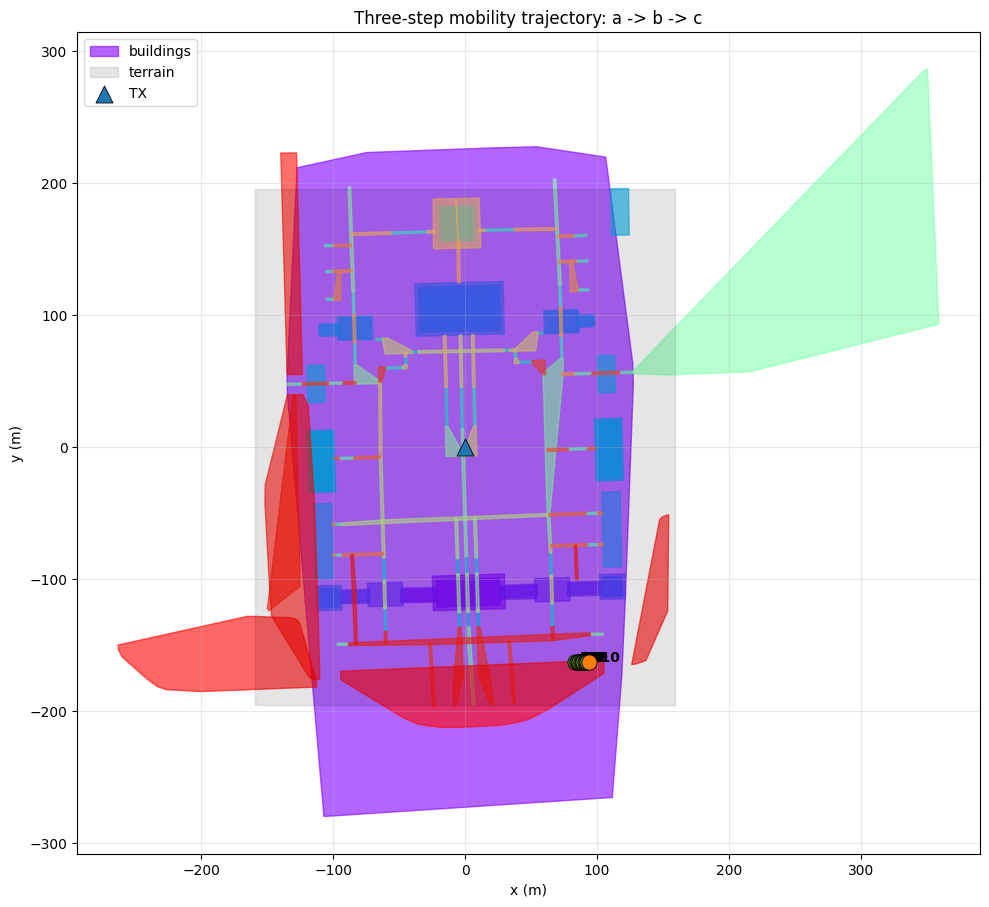

In [36]:
ordered_users, labels, direction = build_three_step_trajectory(plot_dataset, TARGET_USER_INDEX, history_len=HISTORY_LEN)
print('ordered_users:', ordered_users)
print('labels:', labels)
print('direction:', direction)
plot_scene_trajectory(plot_dataset, ordered_users, labels)


## Static channels at a, b, c

These are still **static** channels from DeepMIMO. The dynamic effect comes in the next step, where we apply sequential phase evolution over time.


In [37]:
ch_params = dm.ChannelParameters()
ch_params.shape = np.array([])
plot_dataset.compute_channels(ch_params)

channels = np.asarray(plot_dataset.channels)
scale = 1e6
H_a = squeeze_channel_to_matrix(channels[ordered_users[0]]) 
H_b = squeeze_channel_to_matrix(channels[ordered_users[1]]) 
H_c_static = squeeze_channel_to_matrix(channels[ordered_users[2]])

print('H_a shape:', H_a.shape)
print('H_b shape:', H_b.shape)
print('H_c_static shape:', H_c_static.shape)


The following parameters seem unnecessary:
{'shape'}
No doppler in channel generation because all velocities are zero


Generating channels: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85988/85988 [00:02<00:00, 35326.09it/s]

H_a shape: (8, 1)
H_b shape: (8, 1)
H_c_static shape: (8, 1)


## Sequential dynamic evolution

This is a deliberately simple model.

We use a per-step Doppler phase rotation:

$$H_{t+1}^{dyn} = H_{t+1}^{static} \odot e^{j 2\pi f_D \Delta t (t+1)}$$

The important point is not the exact physics of every path here. The point is to show that once time accumulates across `a -> b -> c`, the final instantaneous channel differs from a static channel at `c`.

We also compare against a stale quasi-static prior from `b`, which is closer to how a PathFormer prior would be used in a dynamic setting.


In [45]:
def scalar_doppler_phase(doppler_hz, dt_seconds, step_idx):
    return np.exp(1j * 2 * np.pi * doppler_hz * dt_seconds * step_idx).astype(np.complex64)


def apply_scalar_doppler(H_static, doppler_hz, dt_seconds, step_idx):
    return H_static * scalar_doppler_phase(doppler_hz, dt_seconds, step_idx)


H_a_dyn = apply_scalar_doppler(H_a, DOPPLER_HZ, DT_SECONDS, step_idx=9)
H_b_dyn = apply_scalar_doppler(H_b, DOPPLER_HZ, DT_SECONDS, step_idx=10)
H_c_dyn = apply_scalar_doppler(H_c_static, DOPPLER_HZ, DT_SECONDS, step_idx=11)

# A stale prior from b: what a quasi-static prior would have predicted one step earlier.
H_prior_from_b = H_b

print('phase(a):', scalar_doppler_phase(DOPPLER_HZ, DT_SECONDS, 9))
print('phase(b):', scalar_doppler_phase(DOPPLER_HZ, DT_SECONDS, 10))
print('phase(c):', scalar_doppler_phase(DOPPLER_HZ, DT_SECONDS, 11), 'orign', )


phase(a): (0.9951074+0.09879873j)
phase(b): (0.993961+0.10973431j)
phase(c): (0.9926943+0.12065663j) orign


In [39]:
DOPPLER_HZ

3500.0

## Compare static vs dynamic vs stale prior

We compare magnitude and phase differences.

In a real experiment, the PathFormer prior would be more structured than just `H_b`, but this is enough to illustrate the mismatch you care about.


In [46]:
def nmse(reference, estimate):
    num = np.sum(np.abs(reference - estimate) ** 2)
    den = np.sum(np.abs(reference) ** 2) + 1e-12
    return float(num / den)


def phase_mae_deg(reference, estimate):
    delta = np.angle(estimate) - np.angle(reference)
    delta = (delta + np.pi) % (2 * np.pi) - np.pi
    return float(np.mean(np.abs(delta)) * 180.0 / np.pi)


metrics = pd.DataFrame([
    {
        'comparison': 'static_c vs dynamic_c',
        'nmse': nmse(H_c_dyn, H_c_static),
        'phase_mae_deg': phase_mae_deg(H_c_dyn, H_c_static),
    },
    {
        'comparison': 'prior_b vs dynamic_c',
        'nmse': nmse(H_c_dyn, H_prior_from_b),
        'phase_mae_deg': phase_mae_deg(H_c_dyn, H_prior_from_b),
    },
    {
        'comparison': 'static_c vs prior_b',
        'nmse': nmse(H_prior_from_b, H_c_static),
        'phase_mae_deg': phase_mae_deg(H_prior_from_b, H_c_static),
    },
])
metrics


,comparison,nmse,phase_mae_deg
0,static_c vs dynamic_c,1.145550e-10,6.930002
1,prior_b vs dynamic_c,6.289897e-10,15.783280
2,static_c vs prior_b,2.081659e-10,8.853281


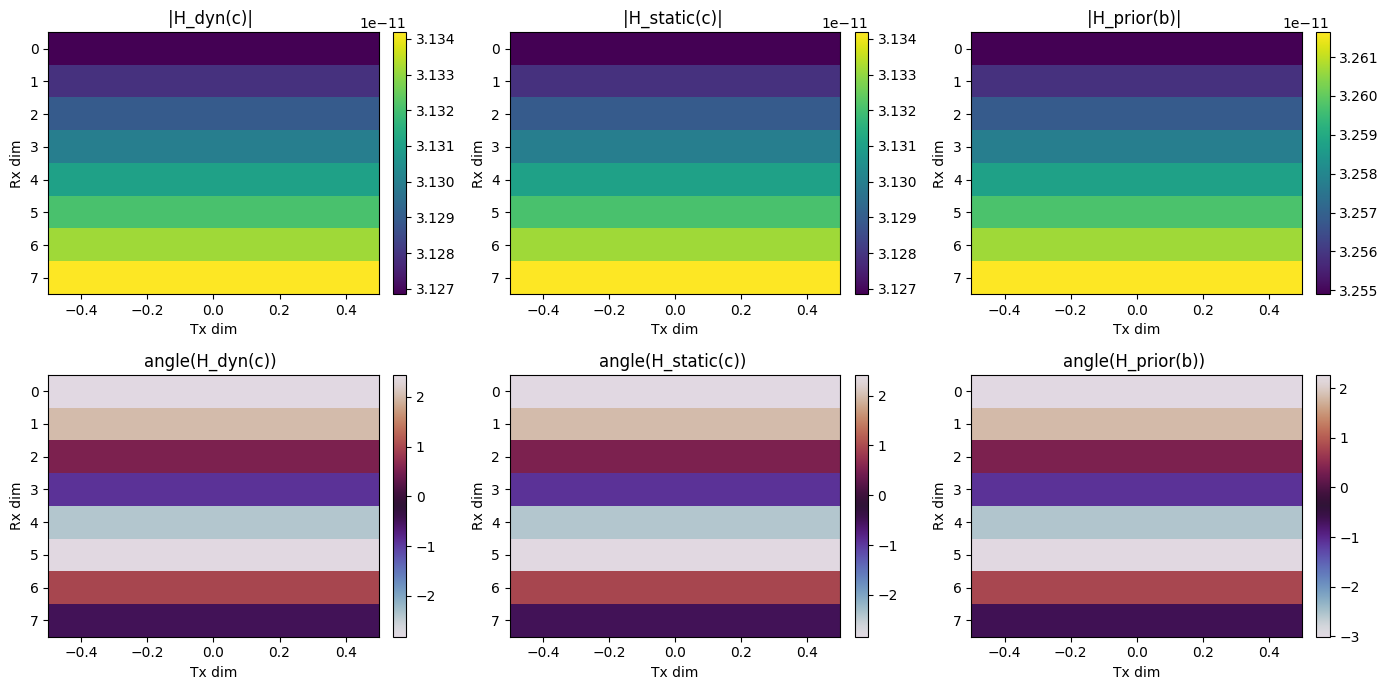

In [41]:
def plot_channel_triplet(H_ref, H_static, H_prior, title_suffix=''):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))

    mats = [
        (np.abs(H_ref), f'|H_dyn(c)| {title_suffix}'),
        (np.abs(H_static), f'|H_static(c)| {title_suffix}'),
        (np.abs(H_prior), f'|H_prior(b)| {title_suffix}'),
        (np.angle(H_ref), f'angle(H_dyn(c)) {title_suffix}'),
        (np.angle(H_static), f'angle(H_static(c)) {title_suffix}'),
        (np.angle(H_prior), f'angle(H_prior(b)) {title_suffix}'),
    ]

    cmaps = ['viridis', 'viridis', 'viridis', 'twilight', 'twilight', 'twilight']
    for ax, (mat, title), cmap in zip(axes.flat, mats, cmaps):
        im = ax.imshow(mat, aspect='auto', cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel('Tx dim')
        ax.set_ylabel('Rx dim')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_channel_triplet(H_c_dyn, H_c_static, H_prior_from_b)


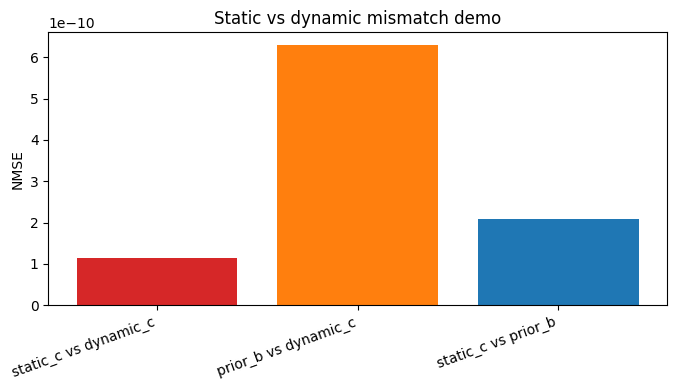

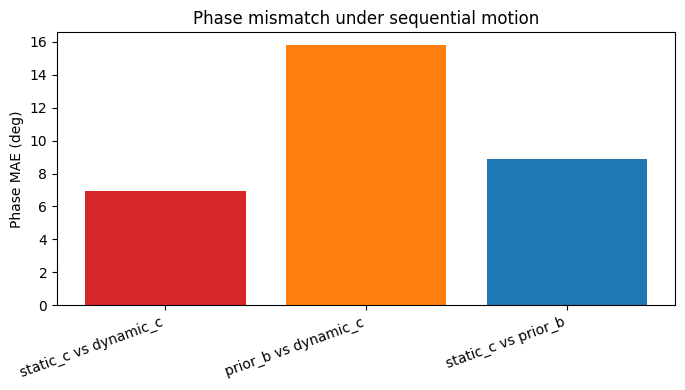

In [47]:
plt.figure(figsize=(7, 4))
plt.bar(metrics['comparison'], metrics['nmse'], color=['tab:red', 'tab:orange', 'tab:blue'])
plt.ylabel('NMSE')
plt.title('Static vs dynamic mismatch demo')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(metrics['comparison'], metrics['phase_mae_deg'], color=['tab:red', 'tab:orange', 'tab:blue'])
plt.ylabel('Phase MAE (deg)')
plt.title('Phase mismatch under sequential motion')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## Takeaway

This notebook is only a minimal illustration, but it makes the key point:

- If you care about **dynamic instantaneous CSI**, a static prior at the final geometry is not the same as the true time-evolved channel.
- A stale or quasi-static prior can still be useful, but it is no longer an oracle.
- That is the right setup for arguing that PathFormer can support online channel estimation under mobility and Doppler.

The next step after this toy demo would be to replace the simple scalar Doppler rotation with:
- per-path Doppler
- pilot corruption / SNR control
- and a real estimator-fusion experiment with LWM / WiFo / another channel model.
